# Part 1: The Wind Resource [40 pts]

Site: **54.091 N, 3.741 W**: Irish Sea, off the Cumbria coast, UK.

Data: hourly wind speed at 10 m height for 2025, downloaded from [NASA POWER](https://power.larc.nasa.gov/).

In [1]:
import sys
from pathlib import Path
sys.path.append("../../src")  

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from windtools import weibull

figures_dir = Path("../figures")
figures_dir.mkdir(exist_ok=True)

# NASA POWER hourly exports have a ~10-line metadata header before the actual data
df = pd.read_csv("../../data/wind/POWER_Point_Hourly_20250101_20251231_054d09N_003d74W_LST.csv", skiprows=10)
wind_10m = df["WS10M"].to_numpy()

## Normalized histogram / PDF, mean and standard deviation [10 pts]

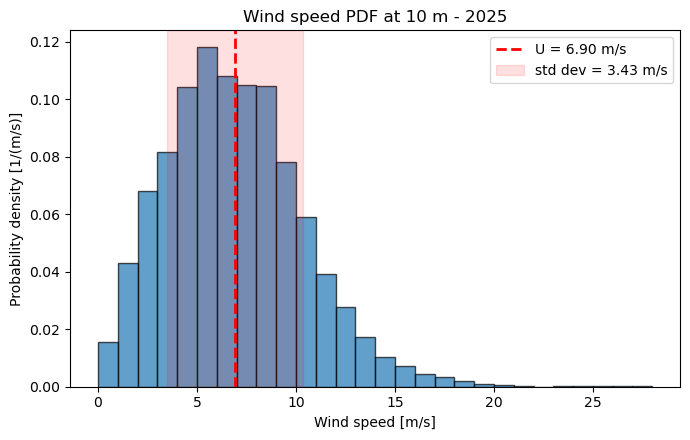

In [2]:
U = wind_10m.mean()
sigma = wind_10m.std(ddof=1)
bins = np.arange(0, np.ceil(wind_10m.max()) + 1, 1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(wind_10m, bins=bins, density=True, edgecolor="black", alpha=0.7)
ax.axvline(U, color="red", linestyle="--", linewidth=2, label=f"U = {U:.2f} m/s")
ax.axvspan(U - sigma, U + sigma, color="red", alpha=0.12, label=f"std dev = {sigma:.2f} m/s")
ax.set_xlabel("Wind speed [m/s]")
ax.set_ylabel("Probability density [1/(m/s)]")
ax.set_title("Wind speed PDF at 10 m - 2025")
ax.legend()
fig.tight_layout()
fig.savefig(figures_dir / "wind_speed_histogram.png", dpi=300)

## Weibull parameters via the graphical (least-squares) method [20 pts]



k = 2.062, c = 7.826 m/s, R^2 = 0.9980


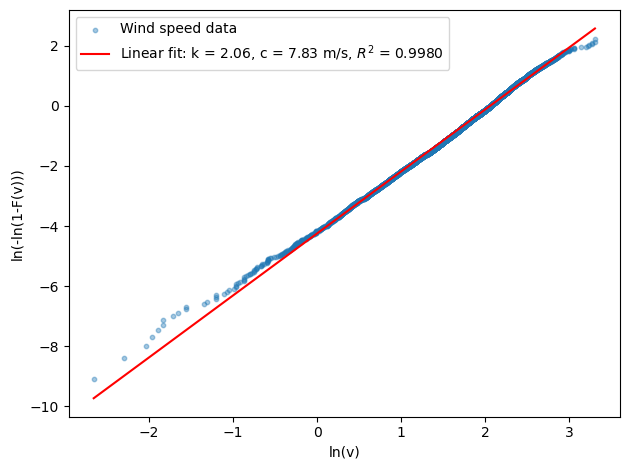

In [3]:
k, c, r2, x, y = weibull.fit_weibull_lsq(wind_10m)
print(f"k = {k:.3f}, c = {c:.3f} m/s, R^2 = {r2:.4f}")

plt.scatter(x, y, s=10, alpha=0.4, label="Wind speed data")
plt.plot(x, k * x - k * np.log(c), color="red", label=f"Linear fit: k = {k:.2f}, c = {c:.2f} m/s, $R^2$ = {r2:.4f}")
plt.xlabel("ln(v)"); plt.ylabel("ln(-ln(1-F(v)))"); plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "weibull_linear_regression.png", dpi=300)

## Weibull fit overlaid on histogram + RMSE [5 pts]

RMSE = 0.00455


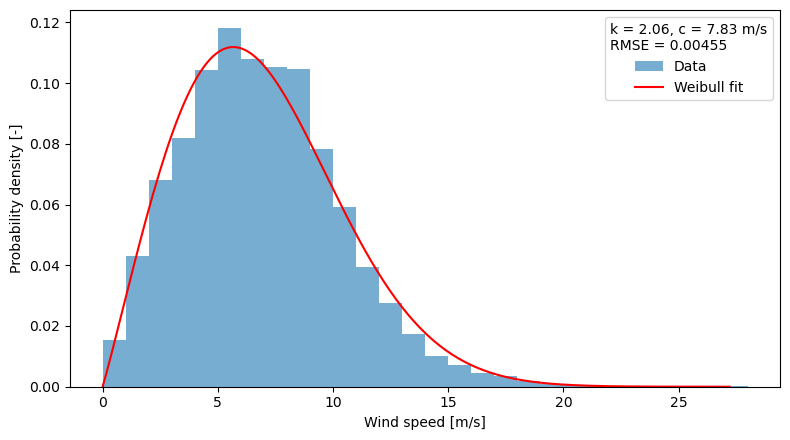

In [4]:
v_range = np.linspace(0.01, wind_10m.max(), 200)
rmse = weibull.rmse_pdf(wind_10m, k, c, bin_width=1.0)

plt.figure(figsize=(8, 4.5))
plt.hist(wind_10m, bins=np.arange(0, wind_10m.max() + 1, 1), density=True, alpha=0.6, label="Data")
plt.plot(v_range, weibull.weibull_pdf(v_range, k, c), color="red", label="Weibull fit")
plt.xlabel("Wind speed [m/s]"); plt.ylabel("Probability density [-]")
plt.legend(loc="upper right", title=f"k = {k:.2f}, c = {c:.2f} m/s\nRMSE = {rmse:.5f}")
plt.tight_layout()
plt.savefig(figures_dir / "weibull_distribution_fit.png", dpi=300)

print(f"RMSE = {rmse:.5f}")